# 1 - Loading the cleaned data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("../data/processed/cleaned_data.csv")

# 2 - Train K-Means for several values of K

In [16]:
inertia = []
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
for k in range(1,11) :
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

print(inertia)

[6144.0, 4778.8244259945195, 4135.216560002947, 3837.111021883577, 3550.004081789292, 3331.1288948812376, 3176.3340052089466, 3002.0794479605024, 2912.9511524995532, 2815.7140801518185]


# 3 - Elbow Method

<function matplotlib.pyplot.show(close=None, block=None)>

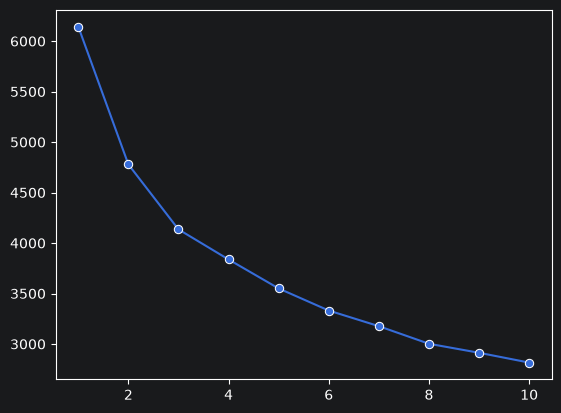

In [17]:
k_range = [1,2,3,4,5,6,7,8,9,10]
sns.lineplot(x=k_range,y=inertia,marker='o')
plt.show

# 4 - Silhouette Score

<function matplotlib.pyplot.show(close=None, block=None)>

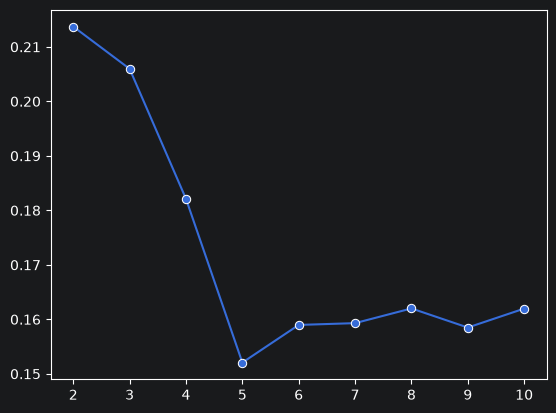

In [18]:
silhouette_scores = []

for k in range(2,11) :
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled,labels)
    silhouette_scores.append(score)

sns.lineplot(x=range(2,11),y=silhouette_scores,marker='o')
plt.show

# 5 - Train Final K-Means

In [19]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

kmeans = KMeans(n_clusters=3,random_state=42)
kmeans.fit(df_scaled)
df["cluster"] = kmeans.predict(df_scaled)

print(df.head(5))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    169.0  33.6   
1            1     85.0           66.0           29.0     58.6  26.6   
2            8    183.0           64.0           25.8    164.6  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  cluster  
0                     0.627   50        1  
1                     0.351   31        2  
2                     0.672   32        1  
3                     0.167   21        2  
4                     2.288   33        0  


# 6 - Clusters analysis

In [25]:
print(df["cluster"].value_counts())
feature_means = df.groupby("cluster").mean()
print("\n")
print(feature_means))

cluster
2    329
1    233
0    206
Name: count, dtype: int64


         Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
cluster                                                                      
0           2.106796  137.578641      74.767961      36.689320  197.916748   
1           7.493562  132.909871      78.466953      30.389700  164.945064   
2           2.349544  103.581155      66.581763      23.261398   97.111626   

               BMI  DiabetesPedigreeFunction        Age  
cluster                                                  
0        38.358010                  0.582665  29.126214  
1        32.520901                  0.456356  46.446352  
2        28.496018                  0.413498  26.465046  
Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age 

# 7 - Visualizing Clusters Distributions

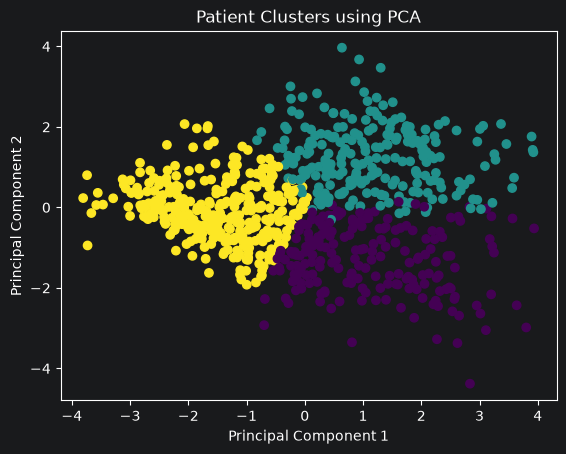

In [24]:
clusters = kmeans.fit_predict(df_scaled)

pca = PCA(n_components=2)

x_pca = pca.fit_transform(df_scaled)

plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=clusters
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Patient Clusters using PCA")

plt.show()

# 8 - Interpret each cluster

In [30]:
df["Diabete_risk"] = np.where(df["cluster"] == 0 , "High" , np.where(df["cluster"] == 1 , "Moderate" , "Low"))
df = df.drop(columns=["cluster"])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabete_risk
0,6,148.0,72.0,35.0,169.0,33.6,0.627,50,Moderate
1,1,85.0,66.0,29.0,58.6,26.6,0.351,31,Low
2,8,183.0,64.0,25.8,164.6,23.3,0.672,32,Moderate
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,Low
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,High


# 9 - Loading the interpreted dataset

In [31]:
df.to_csv("../data/processed/interpreted_data.csv",index=False)